**Forecasting**

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


# LOAD DATA

path = "Merged_1.csv"
df = pd.read_csv(path)

df = df.drop(['country_region', 'date.1'], axis=1, errors='ignore')

df = df.rename(columns={
    'location.1': 'Country',
    'total_deaths': 'TotalDeaths',
    'date': 'Date',
    'retail_and_recreation_percent_change_from_baseline': 'Retail and Recreation',
    'grocery_and_pharmacy_percent_change_from_baseline': 'Grocery and Pharmacy',
    'parks_percent_change_from_baseline': 'Parks',
    'transit_stations_percent_change_from_baseline': 'Transit Stations',
    'workplaces_percent_change_from_baseline': 'Workplaces',
    'residential_percent_change_from_baseline': 'Residential'
})

df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df = df.sort_values(['Country', 'Date']).reset_index(drop=True)
df['time_step'] = df.groupby('Country').cumcount()

time_series_features = [
    'Retail and Recreation',
    'Grocery and Pharmacy',
    'Parks',
    'Transit Stations',
    'Workplaces',
    'Residential'
]

for col in time_series_features:
    df[col] = df.groupby('Country')[col].transform(
        lambda x: x.interpolate().ffill().bfill()
    )
    df[col] = df.groupby('Country')[col].transform(
        lambda x: StandardScaler().fit_transform(x.values.reshape(-1,1)).ravel()
    )

df['TotalDeaths'] = df['TotalDeaths'].fillna(0)

daily = df.groupby('Country')['TotalDeaths'].diff().fillna(0).clip(lower=0)
df['CumulativeDeaths'] = daily.groupby(df['Country']).cumsum()

df['cumulative_norm'] = df.groupby('Country')['CumulativeDeaths'].transform(
    lambda x: x / (x.max() if x.max() > 0 else 1.0)
)

In [3]:
class Seq2SeqDataset(Dataset):
    def __init__(self, df, enc_len=100, dec_len=30):
        self.samples = []
        self.enc_len = enc_len
        self.dec_len = dec_len
        
        for country, g in df.groupby('Country'):
            g = g.sort_values('time_step').reset_index(drop=True)
            if len(g) >= enc_len + dec_len:
                x_enc = g[time_series_features].iloc[:enc_len].values.astype(np.float32)
                y_train = g['cumulative_norm'].iloc[:enc_len].values.astype(np.float32)
                y_future = g['cumulative_norm'].iloc[enc_len:enc_len+dec_len].values.astype(np.float32)
                
                self.samples.append((x_enc, y_train, y_future, country))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        x_enc, y_train, y_future, country = self.samples[idx]
        return (
            torch.tensor(x_enc),
            torch.tensor(y_train),
            torch.tensor(y_future),
            country
        )

In [4]:
class Seq2SeqRecursive(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, dropout=0.3):
        super().__init__()
        
        self.encoder = nn.LSTM(
            input_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        
        self.decoder = nn.LSTM(
            1, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x_enc, y_train, future_steps=30):
        
                                        # Encoder
        _, (h, c) = self.encoder(x_enc)

       
                                       #  Reconstruct first 100 days
       
        dec_in = y_train.unsqueeze(-1)
        dec_out, (h, c) = self.decoder(dec_in, (h, c))
        pred_train = F.softplus(self.fc(dec_out)).squeeze(-1)

       
                                      #  Recursive future forecast
        
        decoder_input = pred_train[:, -1].unsqueeze(1).unsqueeze(-1)

        future_preds = []

        for _ in range(future_steps):
            dec_out, (h, c) = self.decoder(decoder_input, (h, c))
            pred = F.softplus(self.fc(dec_out))
            future_preds.append(pred)
            decoder_input = pred

        pred_future = torch.cat(future_preds, dim=1).squeeze(-1)

        return pred_train, pred_future

In [5]:
def train_model(model, loader, epochs=500, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        
        for x_enc, y_train, y_future, _ in loader:
            optimizer.zero_grad()

            pred_train, pred_future = model(
                x_enc, y_train, future_steps=y_future.shape[1]
            )

            loss1 = criterion(pred_train, y_train)
            loss2 = criterion(pred_future, y_future)

            loss = loss1 + loss2
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        if (epoch+1) % 50 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss={total_loss:.6f}")

    return model

In [6]:
def forecast_country(model, df, country_name, enc_len=100, dec_len=30):
    g = df[df['Country']==country_name].sort_values('time_step').reset_index(drop=True)

    x_enc = g[time_series_features].iloc[:enc_len].values.astype(np.float32)
    y_train = g['cumulative_norm'].iloc[:enc_len].values.astype(np.float32)
    y_future = g['cumulative_norm'].iloc[enc_len:enc_len+dec_len].values.astype(np.float32)

    x_enc = torch.tensor(x_enc).unsqueeze(0)
    y_train_t = torch.tensor(y_train).unsqueeze(0)

    model.eval()
    with torch.no_grad():
        pred_train, pred_future = model(x_enc, y_train_t, future_steps=dec_len)

    return y_train, y_future, pred_train.squeeze(0).numpy(), pred_future.squeeze(0).numpy(), g

In [7]:
ENC_LEN = 100
DEC_LEN = 30
BATCH_SIZE = 32
EPOCHS = 2000
LR = 1e-2

In [9]:
dataset = Seq2SeqDataset(df, enc_len=ENC_LEN, dec_len=DEC_LEN)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

In [10]:
model = Seq2SeqRecursive(input_dim=len(time_series_features))

In [11]:
model = train_model(model, loader, epochs=EPOCHS, lr=LR)

/home/abbas/anaconda3/lib/python3.13/site-packages/torch/autograd/graph.py:829: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 11040). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 50/2000, Loss=0.166653
Epoch 100/2000, Loss=0.060278
Epoch 150/2000, Loss=0.026754
Epoch 200/2000, Loss=0.013081
Epoch 250/2000, Loss=0.006897
Epoch 300/2000, Loss=0.004428
Epoch 350/2000, Loss=0.003638
Epoch 400/2000, Loss=0.004410
Epoch 450/2000, Loss=0.003129
Epoch 500/2000, Loss=0.001726
Epoch 550/2000, Loss=0.001880
Epoch 600/2000, Loss=0.001559
Epoch 650/2000, Loss=0.001394
Epoch 700/2000, Loss=0.001221
Epoch 750/2000, Loss=0.000918
Epoch 800/2000, Loss=0.001573
Epoch 850/2000, Loss=0.000803
Epoch 900/2000, Loss=0.000733
Epoch 950/2000, Loss=0.000892
Epoch 1000/2000, Loss=0.000598
Epoch 1050/2000, Loss=0.000632
Epoch 1100/2000, Loss=0.000492
Epoch 1150/2000, Loss=0.000782
Epoch 1200/2000, Loss=0.000632
Epoch 1250/2000, Loss=0.000876
Epoch 1300/2000, Loss=0.000497
Epoch 1350/2000, Loss=0.000441
Epoch 1400/2000, Loss=0.004796
Epoch 1450/2000, Loss=0.000665
Epoch 1500/2000, Loss=0.000448
Epoch 1550/2000, Loss=0.000491
Epoch 1600/2000, Loss=0.000404
Epoch 1650/2000, Loss=0.0004

In [12]:
country_name = "Nigeria"

true_train, true_future, pred_train, pred_future, g = forecast_country(
    model, df, country_name, enc_len=ENC_LEN, dec_len=DEC_LEN
)

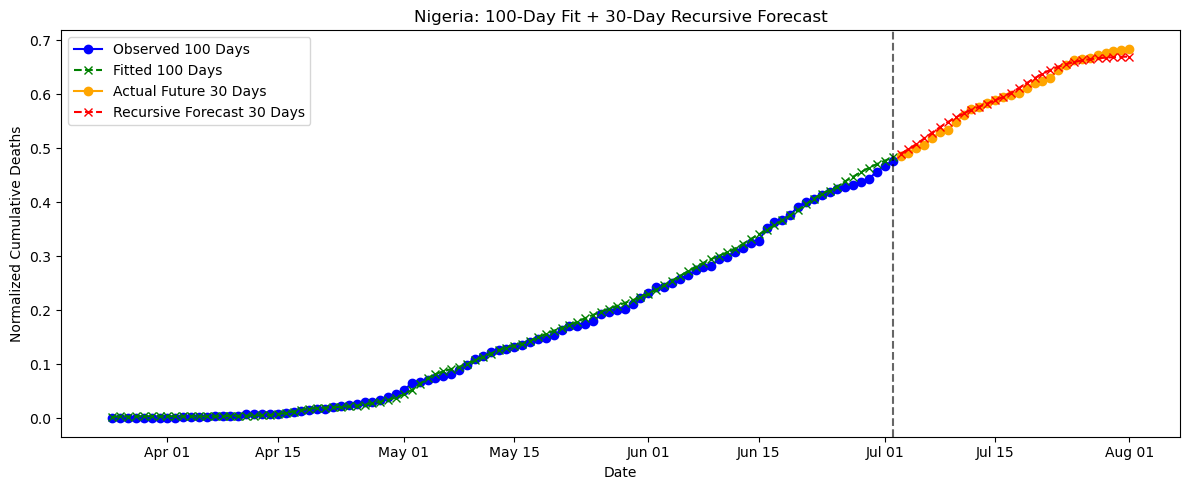

In [13]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

train_dates = g['Date'].iloc[:ENC_LEN]
future_dates = g['Date'].iloc[ENC_LEN:ENC_LEN+DEC_LEN]

plt.figure(figsize=(12,5))

plt.plot(train_dates, true_train, 'o-', color='blue', label='Observed 100 Days')
plt.plot(train_dates, pred_train, 'x--', color='green', label='Fitted 100 Days')

plt.plot(future_dates, true_future, 'o-', color='orange', label='Actual Future 30 Days')
plt.plot(future_dates, pred_future, 'x--', color='red', label='Recursive Forecast 30 Days')

plt.axvline(train_dates.iloc[-1], color='black', linestyle='--', alpha=0.6)

plt.title(f"{country_name}: 100-Day Fit + 30-Day Recursive Forecast")
plt.xlabel("Date")
plt.ylabel("Normalized Cumulative Deaths")
plt.legend()
plt.grid(False)

ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

plt.tight_layout()
plt.show()